# 03 - Validation of the Model

The goal of this notebook is to validate the model created. Before introducing the tournament mechanics with match simulations, we must first ensure that what we built reflects the reality of the ATP tour.

Here, we simulate the life cycle of tennis players over a certain period using the calibrated parameters from the `simulation_params.json` file: we generate a number of new players (18 y.o.) entering the circuit each year, by drawing a potential for each of them based on the calibrated distributions. We then apply the modeled aging curve with random fluctuations to update each player's relative strength. Finally, we also simulate career end usning te probability law based on age.

From these synthetic data, we can compare them directly against the observed ATP data, by validating the stability of the number of active players per year, and the evolution of the career profiles (start age, retirement, top strength,...).

In [152]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
# importing the parameters stored in the .json file
import json

config_path = "../config/simulation_params.json"

with open(config_path, "r") as f:
    config_params = json.load(f)

In [154]:
# import the functio for simulations (from the simulation.py file in the src.)
from simulation import  run_simulation

## 1. Validation of the Stability of Number of New Players per Year
We run the simulation over a long period of years. The initial years correspond to the "warm-up" phase to allow the system to stabilise (let the first generation age and retire). The goal is to compare the number of active players per year from the synthetic data and the observed ones, and to check whether the number of players doesn't fall to 0 or keeps increasing.

In [155]:
start_year_1 = 0
end_year_1 = 100

In [156]:
# 1. Run Simulation
# e.g. from 1950 to 2024 (to have a "warm-up" phase and wait for the data to stabilize)
complete_simulation_data_1 = run_simulation(start_year=start_year_1, end_year=end_year_1, config_params=config_params)
synthetic_active_players = complete_simulation_data_1[complete_simulation_data_1["is_active"] == True]
synthetic_active_per_year = synthetic_active_players.groupby("current_year").size()

# 2. Load Observed Results (Zermelo Strengths)
observed_strengths_path = "../data/processed/zermelo_strengths_1991-2024.csv"
observed_strengths = pd.read_csv(observed_strengths_path, low_memory=False)
observed_active_per_year = observed_strengths.groupby("year").size()

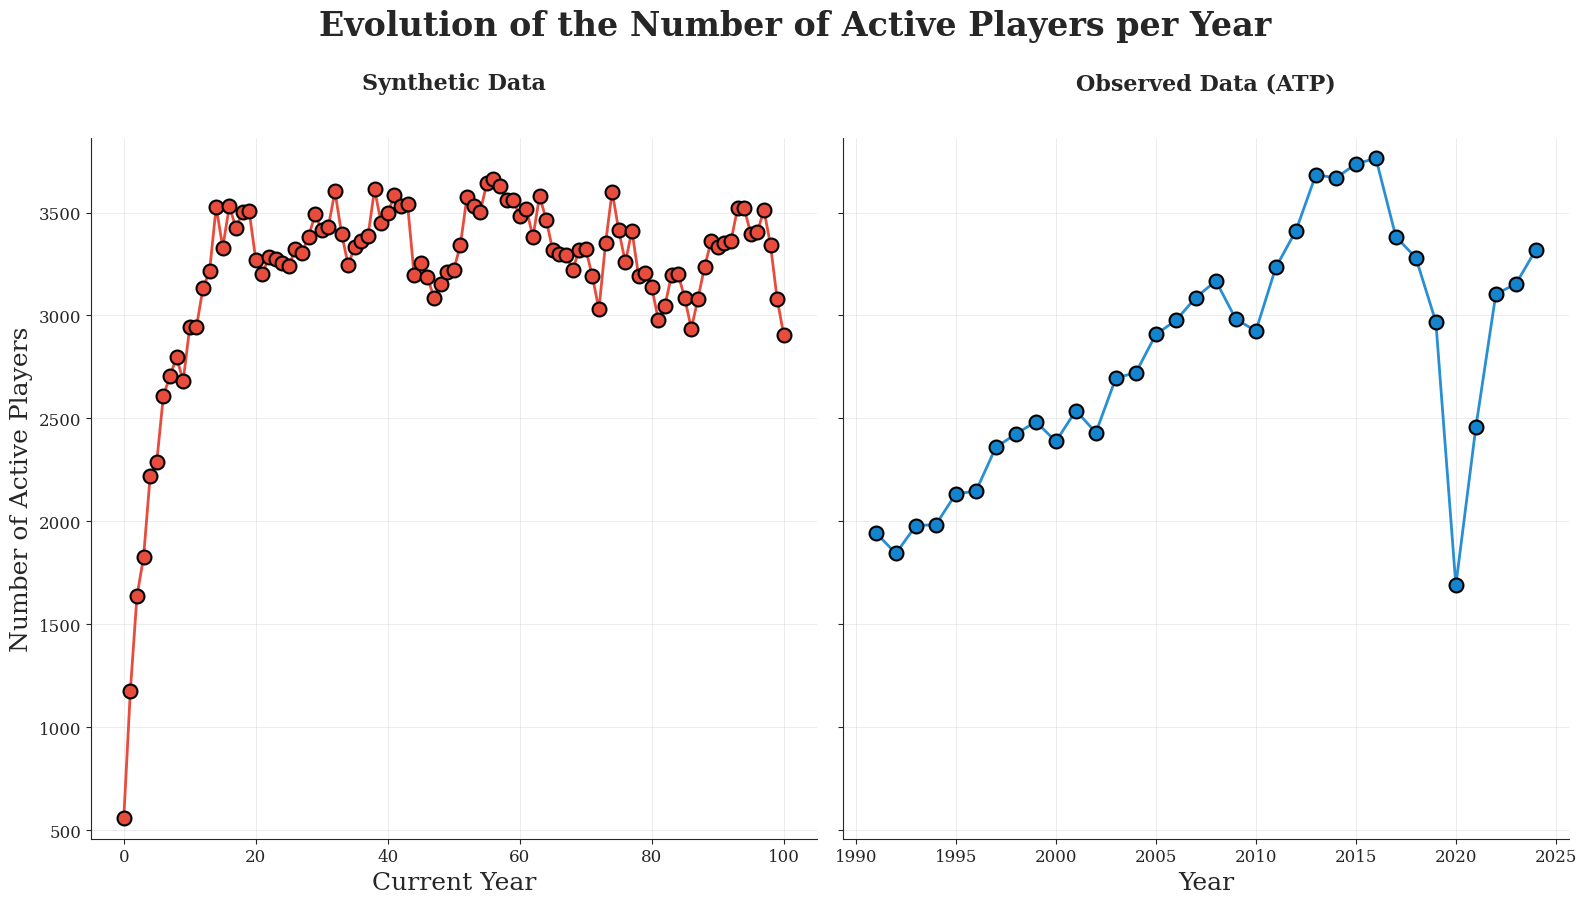

In [157]:
# Plot of the number of active players 

min_number_active = np.min([np.min(synthetic_active_per_year), np.min(observed_active_per_year)])
max_number_active = np.max([np.max(synthetic_active_per_year), np.max(observed_active_per_year)])


plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})


# Plot of the SYNTHETIC Number of Active Players per Year
plt.subplot(1,2,1)
sns.scatterplot(x=synthetic_active_per_year.index, y=synthetic_active_per_year.values, 
                    color="#e74c3c", edgecolor="black", 
                    linewidth=1.5, s=100, alpha=1, 
                    zorder=2)

plt.plot(synthetic_active_per_year.index, synthetic_active_per_year.values, color="#e74c3c", linewidth=2, zorder=1)

plt.title("Synthetic Data", fontsize=16, weight="bold", pad=35)
plt.xlabel("Current Year", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.ylabel("Number of Active Players", fontsize=18)
plt.ylim(min_number_active-100, max_number_active+100)
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)


# Plot of the SYNTHETIC Number of Active Players per Year
plt.subplot(1,2,2)
sns.scatterplot(x=observed_active_per_year.index, y=observed_active_per_year.values, 
                    color="#1484cfe8", edgecolor="black", 
                    linewidth=1.5, s=100, alpha=1, 
                    zorder=2)

plt.plot(observed_active_per_year.index, observed_active_per_year.values, color="#1484cfe8", linewidth=2, zorder=1)

plt.title("Observed Data (ATP)", fontsize=16, weight="bold", pad=35)
plt.xlabel("Year", fontsize=18)
plt.ylim(min_number_active-100, max_number_active+100)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(axis='y', labelleft=False)
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)

plt.suptitle("Evolution of the Number of Active Players per Year", fontsize=24, weight="bold", y=1.)   
sns.despine()
plt.tight_layout()
plt.show()

Good news here, as the number of players remains quite constant (no drop to 0 or increase to infinity). The number of players for the synthetic data is bigger, but this is expected as we considered the number of new players as constant, and the model doesn't take into account injuries (which would decrease the number of active players each year).

## 2. Validation of the Career Profiles
We now compare the start and end ages for both types of data, as well as the top strength (in log10). The danger here is that some players  (synthetic data) never reached their attributed potential, as they had to retire earlier, which could change the global distribution...

In [158]:
# function keeping only relevant columns from synthetic data that can be compared with the real data 
def get_synthetic_data(simulation_data):

    simulation_data_per_player = simulation_data.groupby("player_id")

    synthetic_data = simulation_data_per_player.agg({
        "age": ["min", "max"],
        "current_strength": ["max"],
        "start_year": ["first"],
    })

    synthetic_data.columns = ["start_age", "end_age", "log10_top_strength", "start_year"]
    synthetic_data["end_age"] -= 1
    synthetic_data = synthetic_data.reset_index()

    return synthetic_data

In [159]:
# Apply the function to get the relevant columns
synthetic_data = get_synthetic_data(complete_simulation_data_1)

# Remove the "warm_up" phase, and the last 10 years (to avoid right-censoring, as for the observed data)
synthetic_data_filtered = synthetic_data[(synthetic_data["start_year"]>=start_year_1+15) &
                                        (synthetic_data["start_year"]<=end_year_1-10)].copy()

# Load the observed career data (calibration players)
observed_data_path = "../data/processed/calibration_players_1992-2014.csv"
observed_data = pd.read_csv(observed_data_path, low_memory=False)
# display(observed_data)

### 2.1. End Ages Comparison
Here we aim to compare the distributions from both datasets for the ending age, to see whether the model reproduces well the retirement process.

In [161]:
synthetic_data_filtered["end_age"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    51719.000000
mean        21.886077
std          4.174027
min         18.000000
25%         19.000000
50%         20.000000
75%         24.000000
95%         31.000000
max         44.000000
Name: end_age, dtype: float64

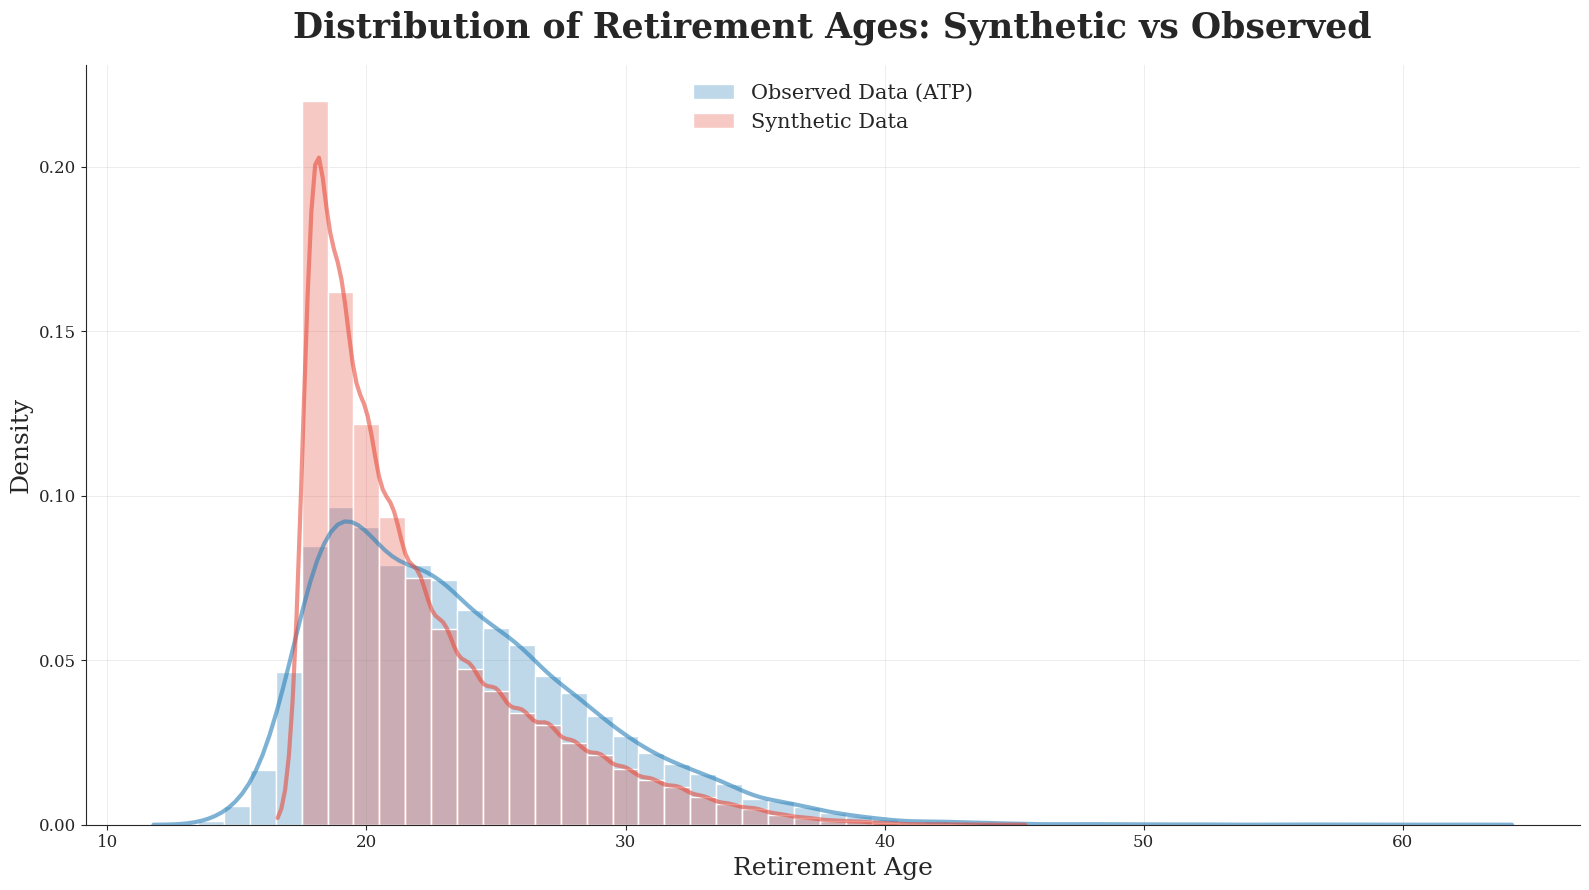

In [163]:
# Plot of the end ages histogram (comparison between observed and synthetic data)

plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})

# plot of the OBSERVED data
sns.histplot(data=observed_data, x="end_age",
            color="#2980b9",alpha=0.3, stat="density", 
            discrete=True, common_norm=False,
            zorder=1, label="Observed Data (ATP)")

sns.kdeplot(data=observed_data, x="end_age", 
            color = "#2980b9", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)

# plot of the SYNTHETIC data
sns.histplot(data=synthetic_data_filtered, x="end_age",
            color="#e74c3c",alpha=0.3, stat="density", 
            discrete=True, common_norm=False,
            zorder=1, label="Synthetic Data")

sns.kdeplot(data=synthetic_data_filtered, x="end_age", 
            color = "#e74c3c", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)


plt.title("Distribution of Retirement Ages: Synthetic vs Observed", fontsize=25, weight="bold", pad=20)
plt.xlabel("Retirement Age", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(frameon=False, fontsize=15, loc="upper center")
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

### 2.2. Top Strength Achieved Comparison

In [164]:
synthetic_data_filtered["log10_top_strength"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    51719.000000
mean        -0.298546
std          0.379802
min         -2.052055
25%         -0.545173
50%         -0.371001
75%         -0.150891
95%          0.489453
max          1.893327
Name: log10_top_strength, dtype: float64

In [165]:
observed_data["log10_top_strength"].describe(percentiles=[0.25, 0.5, 0.75, 0.95])

count    15679.000000
mean        -0.215585
std          0.347195
min         -1.431388
25%         -0.420682
50%         -0.279321
75%         -0.097277
95%          0.501927
max          2.468258
Name: log10_top_strength, dtype: float64

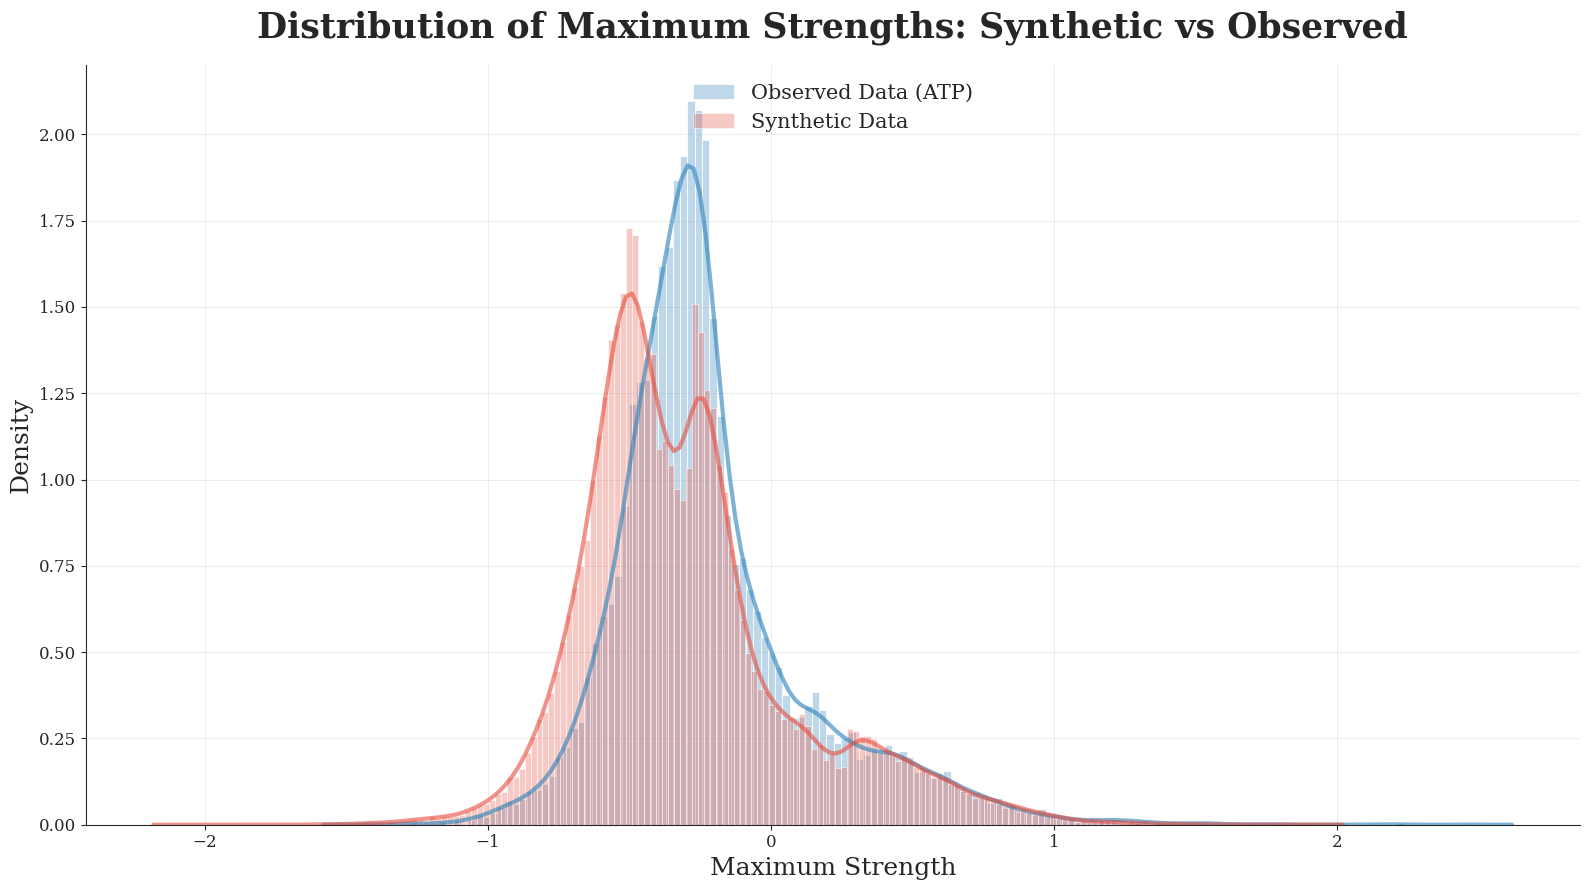

In [166]:
# Plot of the end ages histogram (comparison between observed and synthetic data)

plt.figure(figsize=(16, 9))
sns.set_style("ticks")
plt.rcParams.update({'font.family': 'serif'})

# plot of the OBSERVED data
sns.histplot(data=observed_data, x="log10_top_strength",
            color="#2980b9",alpha=0.3, stat="density", 
            bins="auto", common_norm=False,
            zorder=1, label="Observed Data (ATP)")

sns.kdeplot(data=observed_data, x="log10_top_strength", 
            color = "#2980b9", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)

# plot of the SYNTHETIC data
sns.histplot(data=synthetic_data_filtered, x="log10_top_strength",
            color="#e74c3c",alpha=0.3, stat="density", 
            bins="auto", common_norm=False,
            zorder=1, label="Synthetic Data")

sns.kdeplot(data=synthetic_data_filtered, x="log10_top_strength", 
            color = "#e74c3c", alpha=0.6, 
            linewidth=3, zorder=2, common_norm=False)


plt.title("Distribution of Maximum Strengths: Synthetic vs Observed", fontsize=25, weight="bold", pad=20)
plt.xlabel("Maximum Strength", fontsize=18)
plt.ylabel("Density", fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(frameon=False, fontsize=15, loc="upper center")
plt.grid(visible=True, which="major", axis="both", linewidth=0.5, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()